# 실습 6: 쓸 수 있는 표 한 벌로 만들기
- 상황: 쓸 수 없는 열은 걸러냈는데 아직도 수백 개가 남았다
- 목표: 겹치는 센서를 묶고 관련 있는 것부터 남겨 정제본 한 벌을 만든다

## Step 0. 폴더와 노트북 만들고, 앞 실습 선별까지 다시 만들기

In [1]:
import pandas as pd

df = pd.read_csv("../../data/04_secom.csv")

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

# 센서 열마다 빈칸 비율 / 값 종류 수 / 표준편차 계산
빈칸비율 = df[sensor_cols].isna().mean() * 100
값종류수 = df[sensor_cols].nunique()
표준편차 = df[sensor_cols].std()

# 셋 중 하나라도 해당하면 제외 대상
제외 = (빈칸비율 >= 50) | (값종류수 == 1) | (표준편차 <= 0.001)
남는센서 = [c for c in sensor_cols if not 제외[c]]

# 센서가 아닌 열(measured_at, result)은 그대로 유지
기타열 = [c for c in df.columns if not c.startswith("sensor_")]

# 원본 df는 그대로 두고, 새 표 df1을 만든다
df1 = df[기타열 + 남는센서]

print("원본 df 행 수, 열 수:", df.shape)
print("df1 행 수, 열 수:", df1.shape)


원본 df 행 수, 열 수: (1567, 592)
df1 행 수, 열 수: (1567, 438)


## Step 1. 겹친다는 게 무슨 뜻인지 눈으로 보기

### 두 센서를 나란히 그려본다
같은 것을 재고 있는 것처럼 보이는 짝이 있는지 확인한다.

고른 센서: sensor_177 / sensor_448


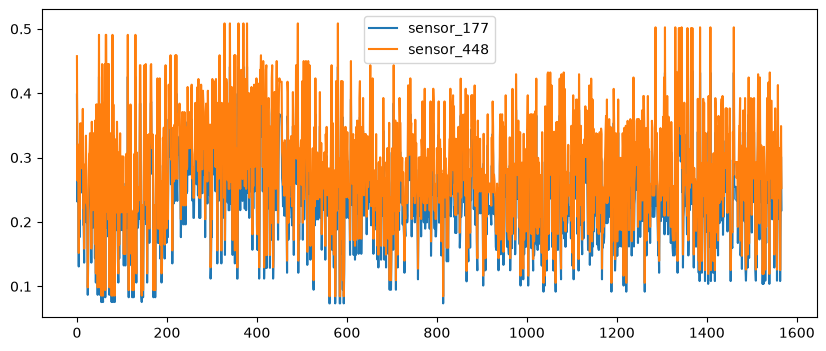

In [2]:
import matplotlib.pyplot as plt

# 실제로 겹치는 것으로 확인된 짝 (겹친다는 게 어떤 모양인지 보려고 미리 골라둔 두 개)
센서A = "sensor_177"
센서B = "sensor_448"

print("고른 센서:", 센서A, "/", 센서B)

# figure() - 그림판 하나를 편다. figsize 는 가로세로 크기(인치)
plt.figure(figsize=(10, 4))

# plot() - 값을 순서대로 선으로 잇는다. label 은 범례에 표시될 이름
plt.plot(df1[센서A].values, label=센서A)
plt.plot(df1[센서B].values, label=센서B)

# legend() - 어느 선이 무엇인지 알려주는 상자를 띄운다
plt.legend()
plt.show()

## Step 2. 겹치는 정도를 숫자로 재보기

### 용어 풀이 - 열끼리의 관계를 말할 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 상관관계 (correlation) | 두 열이 얼마나 같이 움직이는지. -1에서 1 사이의 숫자로 잰다 |
| 상관계수 1에 가깝다 | 하나가 오르면 다른 하나도 같이 오른다 |
| 상관계수 -1에 가깝다 | 하나가 오르면 다른 하나는 내려간다. 이것도 "관계가 강한" 것이다 |
| 상관계수 0에 가깝다 | 서로 상관없이 따로 논다 |
| 다중공선성 | 같은 말을 하는 열이 여러 개 섞여 있는 상태. 같은 정보를 여러 번 세는 셈이 된다 |
| 표준화 (standardization) | 값을 "평균에서 표준편차 몇 배 떨어졌나"로 바꿔 적는 것. 단위가 다른 열을 같은 자로 재게 된다 |
| 변수 선택 (feature selection) | 쓸 열을 골라내는 일 전체. 오늘 하는 일에 붙은 이름 |
| 관련도 | 이 실습에서 쓰는 말. 그 센서와 불량 여부(1/0)의 상관계수 절댓값을 가리킨다 |

**상관관계가 높다고 원인은 아니다.**<br>
아이스크림 판매량과 익사 사고는 같이 오르내리지만, 아이스크림이 원인은 아니다.<br>
둘 다 여름이라 그렇다. 숫자가 높게 나와도 "관계가 있어 보인다"까지만 말한다.

In [3]:
# corr() - 두 열이 얼마나 같이 움직이는지 -1 ~ 1 사이 숫자로 계산한다
겹침정도 = df1[센서A].corr(df1[센서B])

print(센서A, "와", 센서B, "의 상관계수:", round(겹침정도, 4))

sensor_177 와 sensor_448 의 상관계수: 0.9999


## Step 3. 서로 너무 닮은 센서 골라내기
센서 열끼리 상관계수를 구해 절댓값 0.9 이상인 짝을 찾는다. 겹치는 짝은 빈칸이 더 적은 쪽만 남기고 `df2`를 만든다.

In [4]:
import numpy as np

# 남은 센서 열끼리만 상관계수 행렬을 구한다
상관 = df1[남는센서].corr()

# 위쪽 삼각형만 남긴다 (자기 자신과의 상관, 중복된 짝을 빼기 위해)
mask = np.triu(np.ones(상관.shape), k=1).astype(bool)
상관위 = 상관.where(mask)

# 표를 (열1, 열2, 상관계수) 형태로 길게 펼친다
짝목록 = 상관위.stack().reset_index()
짝목록.columns = ["열1", "열2", "상관계수"]
짝목록["절댓값"] = 짝목록["상관계수"].abs()

# 절댓값 0.9 이상인 짝만 남기고 큰 순으로 정렬
# kind="mergesort" — 동점(예: 상관계수 1.0)일 때도 순서가 매번 똑같이 나오게 고정한다
높은짝 = 짝목록[짝목록["절댓값"] >= 0.9].sort_values("절댓값", ascending=False, kind="mergesort").reset_index(drop=True)

print("절댓값 0.9 이상인 짝 개수:", len(높은짝))
print()
print("상위 10쌍:")
display(높은짝.head(10))


절댓값 0.9 이상인 짝 개수: 342

상위 10쌍:


,열1,열2,상관계수,절댓값
0,sensor_075,sensor_210,1.0,1.0
1,sensor_075,sensor_343,1.0,1.0
2,sensor_075,sensor_348,1.0,1.0
3,sensor_075,sensor_479,1.0,1.0
4,sensor_207,sensor_210,1.0,1.0
5,sensor_210,sensor_343,1.0,1.0
6,sensor_210,sensor_348,1.0,1.0
7,sensor_210,sensor_479,1.0,1.0
8,sensor_343,sensor_348,1.0,1.0
9,sensor_207,sensor_348,1.0,1.0


In [5]:
# 열마다 빈칸 개수를 세어둔다 (짝에서 어느 쪽을 남길지 판단하는 기준)
결측개수 = df1[남는센서].isna().sum()

제거대상 = set()
for _, row in 높은짝.iterrows():
    a, b = row["열1"], row["열2"]
    if a in 제거대상 or b in 제거대상:
        # 이미 한쪽이 제거 대상으로 정해진 짝(연쇄로 겹치는 경우)은 건너뛴다
        continue
    # 빈칸이 더 적은 쪽을 남기고, 나머지를 제거 대상에 넣는다
    if 결측개수[a] <= 결측개수[b]:
        제거대상.add(b)
    else:
        제거대상.add(a)

print("제거 대상 열 수:", len(제거대상))

남길센서 = [c for c in 남는센서 if c not in 제거대상]

# df, df1은 그대로 두고 새 표 df2를 만든다
df2 = df1[기타열 + 남길센서]

print("df1 열 수:", df1.shape[1])
print("df2 열 수:", df2.shape[1])


제거 대상 열 수: 190
df1 열 수: 438
df2 열 수: 248


### 결과 정리 (실행 결과 기준)

절댓값 0.9 이상인 짝: **342쌍**

상위 10쌍 (모두 상관계수 1.0):

| 열1 | 열2 | 상관계수 |
|---|---|---|
| sensor_075 | sensor_210 | 1.0 |
| sensor_075 | sensor_343 | 1.0 |
| sensor_075 | sensor_348 | 1.0 |
| sensor_075 | sensor_479 | 1.0 |
| sensor_207 | sensor_210 | 1.0 |
| sensor_210 | sensor_343 | 1.0 |
| sensor_210 | sensor_348 | 1.0 |
| sensor_210 | sensor_479 | 1.0 |
| sensor_343 | sensor_348 | 1.0 |
| sensor_207 | sensor_348 | 1.0 |

제거 대상: **190개** (겹치는 짝마다 빈칸이 더 적은 열만 남기고 제거)

| 표 | 열 개수 |
|---|---|
| df1 | 438개 |
| df2 | **248개** |

sensor_075/210/479/348/343/207처럼 여러 열이 서로 상관계수 1.0으로 완전히 겹치는 그룹이 있었다. 짝을 하나씩 처리하며 이미 제거 대상으로 정해진 열이 나오면 건너뛰는 방식으로 연쇄된 그룹도 처리했다. (동점 순서가 매번 똑같이 나오도록 코드에 `kind="mergesort"`를 지정해뒀다.)

## Step 4. 단위가 제각각이라는 것 확인하기

### 값의 크기가 열마다 얼마나 다른지 본다
같은 표에 들어 있어도 어떤 열은 0~1, 어떤 열은 수천일 수 있다.

In [6]:
# describe() - 열마다 개수, 평균, 표준편차, 최소, 최대 등을 한 번에 보여준다
# .T - 표를 가로세로 뒤집는다. 열이 많을 때는 세로로 봐야 읽힌다
# head() - 위에서 몇 줄만
df2.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
sensor_001,3014.452896,73.621787,2743.2400,3356.3500
sensor_002,2495.850231,80.407705,2158.7500,2846.4400
sensor_003,2200.547318,29.513152,2060.6600,2315.2667
sensor_004,1396.376627,441.691640,0.0000,3715.0417
sensor_007,101.112908,6.237214,82.1311,129.2522
sensor_008,0.121822,0.008961,0.0000,0.1286
sensor_009,1.462862,0.073897,1.1910,1.6564
sensor_010,-0.000841,0.015116,-0.0534,0.0749
sensor_011,0.000146,0.009302,-0.0349,0.0530
sensor_012,0.964353,0.012452,0.6554,0.9848


In [7]:
# 센서 열들의 평균만 모아서 가장 작은 값과 가장 큰 값을 본다
평균들 = df2.describe().T["mean"]

# idxmin() / idxmax() - 가장 작은(큰) 값이 어느 줄인지 그 이름을 돌려준다
print("평균이 가장 작은 열:", 평균들.idxmin(), "→", 평균들.min())
print("평균이 가장 큰 열:", 평균들.idxmax(), "→", 평균들.max())

평균이 가장 작은 열: sensor_022 → -5618.393610223642
평균이 가장 큰 열: sensor_091 → 8827.536865303431


## Step 4_1. 표준화 계산해보기
평균 1800, 표준편차 100인 열에서, 값이 평균으로부터 표준편차 몇 배만큼 떨어져 있는지 계산한다.

In [8]:
# 예시 열의 평균과 표준편차
평균 = 1800
표준편차 = 100

# 표준화 — (값 - 평균) / 표준편차 = 평균에서 표준편차 몇 배만큼 떨어져 있는지
값1 = 1900
표준화값1 = (값1 - 평균) / 표준편차
print(f"{값1} -> ({값1} - {평균}) / {표준편차} = {표준화값1}   평균보다 한 칸 위")

값2 = 1750
표준화값2 = (값2 - 평균) / 표준편차
print(f"{값2} -> ({값2} - {평균}) / {표준편차} = {표준화값2}   평균보다 반 칸 아래")


1900 -> (1900 - 1800) / 100 = 1.0   평균보다 한 칸 위
1750 -> (1750 - 1800) / 100 = -0.5   평균보다 반 칸 아래


## Step 5. 표준화 전후 비교하기
df2의 센서 열 중 값의 크기(절댓값 평균)가 가장 큰 열과 가장 작은 열을 골라, 표준화 전과 후를 그림으로 비교한다. df2 자체는 바꾸지 않는다.

값의 크기가 가장 큰 열: sensor_091 (절댓값 평균: 8827.5369 )
값의 크기가 가장 작은 열: sensor_115 (절댓값 평균: 0.00012253 )


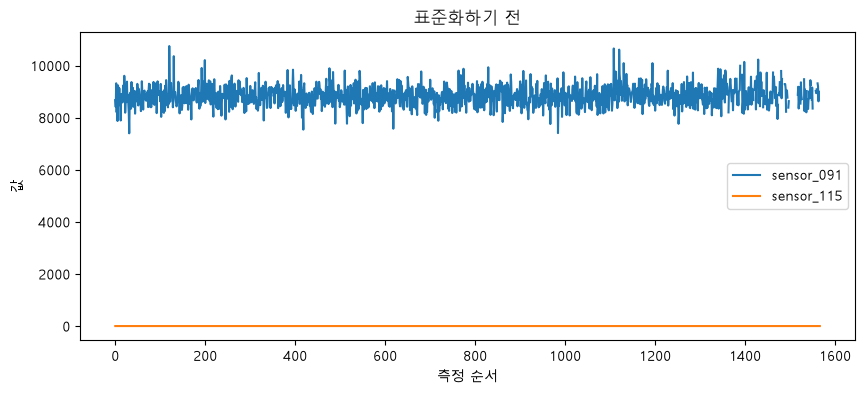

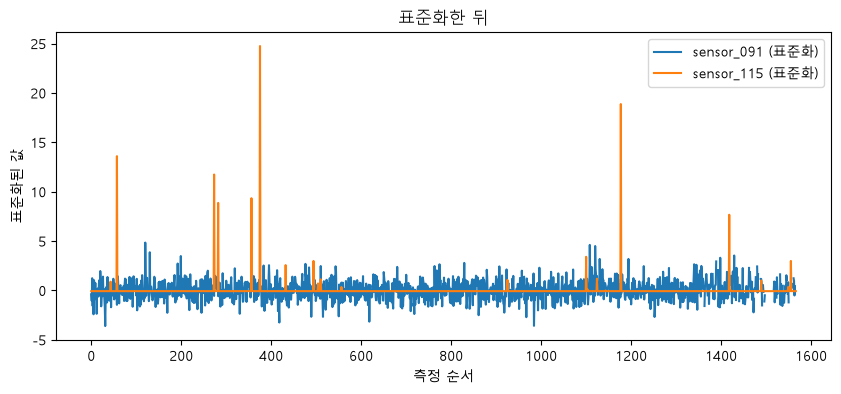

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# df2의 센서 열 중 값의 크기(절댓값 평균)가 가장 큰 열과 가장 작은 열을 고른다
크기 = df2[남길센서].abs().mean()
큰열 = 크기.idxmax()
작은열 = 크기.idxmin()

print("값의 크기가 가장 큰 열:", 큰열, "(절댓값 평균:", round(크기[큰열], 4), ")")
print("값의 크기가 가장 작은 열:", 작은열, "(절댓값 평균:", round(크기[작은열], 8), ")")

# df2는 그대로 두고, 표준화한 값만 따로 계산한다 (평균 0, 표준편차 1이 되도록)
큰열_표준화 = (df2[큰열] - df2[큰열].mean()) / df2[큰열].std()
작은열_표준화 = (df2[작은열] - df2[작은열].mean()) / df2[작은열].std()

# 그림 1 - 표준화하기 전 (원래 값 그대로 겹쳐 그리기)
plt.figure(figsize=(10, 4))
plt.plot(df2[큰열].values, label=큰열)
plt.plot(df2[작은열].values, label=작은열)
plt.title("표준화하기 전")
plt.xlabel("측정 순서")
plt.ylabel("값")
plt.legend()
plt.show()

# 그림 2 - 표준화한 뒤 (평균 0, 표준편차 1로 맞춰서 겹쳐 그리기)
plt.figure(figsize=(10, 4))
plt.plot(큰열_표준화.values, label=f"{큰열} (표준화)")
plt.plot(작은열_표준화.values, label=f"{작은열} (표준화)")
plt.title("표준화한 뒤")
plt.xlabel("측정 순서")
plt.ylabel("표준화된 값")
plt.legend()
plt.show()


### 결과 정리 (실행 결과 기준)

- 값의 크기가 가장 큰 열: **sensor_091** (절댓값 평균 약 8827.5, 평균 8827.5 / 표준편차 396.3)
- 값의 크기가 가장 작은 열: **sensor_115** (절댓값 평균 약 0.00012, 평균 0.00012 / 표준편차 0.00167)

표준화하기 전 그림에서는 sensor_115가 sensor_091에 비해 값이 너무 작아 거의 바닥에 붙은 직선처럼 보인다. 표준화한 뒤 그림에서는 두 열 모두 평균 0을 중심으로 비슷한 규모로 겹쳐 보이고, sensor_115의 튀는 지점(이상치로 보이는 큰 값들)도 그제야 눈에 띈다. df2 자체는 바뀌지 않았고, 표준화한 값은 별도 변수(`큰열_표준화`, `작은열_표준화`)로만 계산했다.

## Step 6. 불량여부와 상관관계 높은 센서 순위
검사 결과를 숫자(불량=1, 양품=0)로 바꾼 `불량여부` 열을 df2에 추가하고, 센서 열마다 이 열과의 상관계수를 구해 순위를 매긴다.

In [10]:
# result 열은 그대로 두고, 숫자로 바꾼 새 열을 추가한다 (불량=1, 양품=0)
df2["불량여부"] = (df2["result"] == "불량").astype(int)

print(df2[["result", "불량여부"]].head())


  result  불량여부
0     양품     0
1     양품     0
2     불량     1
3     양품     0
4     양품     0


C:\Users\solbe\AppData\Local\Temp\ipykernel_39280\3700354017.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2["불량여부"] = (df2["result"] == "불량").astype(int)


In [11]:
# corrwith() — 여러 열을 한 번에 다른 한 열과 상관계수를 구한다
상관계수 = df2[남길센서].corrwith(df2["불량여부"])

rank_table = pd.DataFrame({
    "센서 이름": 상관계수.index,
    "상관계수 절댓값": 상관계수.abs().values,
})

# 절댓값이 큰 순으로 정렬 (kind="mergesort" — 동점 순서 고정)
rank_table = rank_table.sort_values("상관계수 절댓값", ascending=False, kind="mergesort").reset_index(drop=True)

print("상위 20개:")
rank_table.head(20)


상위 20개:


,센서 이름,상관계수 절댓값
0,sensor_060,0.155796
1,sensor_104,0.151203
2,sensor_511,0.131593
3,sensor_432,0.120851
4,sensor_431,0.110067
5,sensor_022,0.108488
6,sensor_029,0.107252
7,sensor_130,0.103373
8,sensor_211,0.102545
9,sensor_164,0.100330


### 결과 정리 (실행 결과 기준)

`rank_table` 상위 20개:

| 순위 | 센서 이름 | 상관계수 절댓값 |
|---|---|---|
| 1 | sensor_060 | 0.155796 |
| 2 | sensor_104 | 0.151203 |
| 3 | sensor_511 | 0.131593 |
| 4 | sensor_432 | 0.120851 |
| 5 | sensor_431 | 0.110067 |
| 6 | sensor_022 | 0.108488 |
| 7 | sensor_029 | 0.107252 |
| 8 | sensor_130 | 0.103373 |
| 9 | sensor_211 | 0.102545 |
| 10 | sensor_164 | 0.100330 |
| 11 | sensor_125 | 0.093994 |
| 12 | sensor_161 | 0.090097 |
| 13 | sensor_317 | 0.089412 |
| 14 | sensor_122 | 0.085004 |
| 15 | sensor_126 | 0.083891 |
| 16 | sensor_027 | 0.081515 |
| 17 | sensor_248 | 0.080991 |
| 18 | sensor_034 | 0.080947 |
| 19 | sensor_181 | 0.078649 |
| 20 | sensor_123 | 0.078378 |

가장 높은 상관계수도 절댓값 0.16이 채 안 된다 — 불량 여부와 강하게 관련된 센서 단독 지표는 없어 보인다. df2 열 수는 `불량여부` 열이 추가되어 249개가 됐다.

## Step 6_1. 1등 센서와 검사 결과의 관계 확인
`rank_table`에서 1등인 센서를 골라, 양품 행과 불량 행 각각에서 그 열의 평균값을 비교한다.

In [12]:
# rank_table의 1등 센서 이름을 가져온다
top1 = rank_table.loc[0, "센서 이름"]
print("1등 센서:", top1)

# 검사 결과(양품/불량)별로 그 열의 평균을 각각 구한다
양품평균 = df2[df2["result"] == "양품"][top1].mean()
불량평균 = df2[df2["result"] == "불량"][top1].mean()

print("양품 평균:", 양품평균)
print("불량 평균:", 불량평균)
print("차이(불량 - 양품):", 불량평균 - 양품평균)


1등 센서: sensor_060
양품 평균: 2.563464217032967
불량 평균: 8.515123076923079
차이(불량 - 양품): 5.951658859890111


### 결과 정리 (실행 결과 기준)

1등 센서: **sensor_060**

| 구분 | 평균 |
|---|---|
| 양품 | 2.5635 |
| 불량 | 8.5151 |
| 차이(불량-양품) | 5.9517 |

불량일 때 평균이 양품일 때보다 약 3.3배 높다. 상관계수 자체는 0.16 정도로 크지 않았지만, 그룹별 평균 차이는 뚜렷하게 벌어져 있다.

## Step 7. 단계별로 몇 개가 되었는지 채워 넣기

### 단계별 열 수

| 단계 | 적용한 기준 | 남은 센서 열 수 |
|---|---|---|
| 시작 | - | 590 |
| 1차 선별 | 빈칸 [50]% 이상 · 상수열 · 표준편차 [0.001] 이하 제외 | [436] |
| 겹침 정리 | 상관계수 절댓값 [0.9] 이상이면 하나만 남김 | [312] |
| 관련도 선별 | 순위 상위 [50]개 | [50] |

### 저장 결과

| 항목 | 값 |
|---|---|
| 정제본 행 수 | [1567] |
| 정제본 열 수 (검사 결과 포함) | [51] |
| 정제본 불합격 비율 | [6.6]% |
| 원본 불합격 비율 | [6.6]% |

## Step 8. 최종 정제본 저장하기
`rank_table` 상위 50개 센서 열과 `result` 열만 남겨 `df3`을 만들고, `results/secom_clean.csv`로 저장한다.

In [13]:
import os

# rank_table 상위 50개 센서 이름
top50 = rank_table.head(50)["센서 이름"].tolist()

# 그 센서 열들과 검사 결과(result) 열만 남긴다
df3 = df2[top50 + ["result"]]

# 이 노트북이 있는 폴더 안 results 폴더에 저장한다
os.makedirs("results", exist_ok=True)
df3.to_csv("results/secom_clean.csv", index=False, encoding="utf-8-sig")

print("df3 행 수, 열 수:", df3.shape)

df3_불량비율 = (df3["result"] == "불량").mean() * 100
df_불량비율 = (df["result"] == "불량").mean() * 100

print("df3 불량 비율:", round(df3_불량비율, 2), "%")
print("원본 df 불량 비율:", round(df_불량비율, 2), "%")


df3 행 수, 열 수: (1567, 51)
df3 불량 비율: 6.64 %
원본 df 불량 비율: 6.64 %


### 결과 정리 (실행 결과 기준)

1. df3 행 수, 열 수: **1567행 × 51열** (센서 50개 + result)
2. df3에서 불량 비율: **6.64%**
3. 원본 df에서 불량 비율: **6.64%**

행은 하나도 안 줄이고 열만 골라냈기 때문에 불량 비율은 df3과 원본 df가 똑같다. `results/secom_clean.csv` 파일로 저장했다.

---
## 직접 해보기 (도전) - 기준을 바꿔 두 번째 정제본 만들기

- 상황: 상위 50개로 잘랐는데, 20개로 자르면 무엇이 달라지는지 아직 모른다
- 할 일: 개수 기준만 바꿔 두 번째 정제본을 만들고 숫자를 비교한다
- 결과물: 정제본 파일 1개 추가 + 세 줄짜리 비교표 1개

In [14]:
# 정제본 B — rank_table 상위 20개 센서 + result
top20 = rank_table.head(20)["센서 이름"].tolist()
df3b = df2[top20 + ["result"]]

df3b.to_csv("results/secom_clean_b.csv", index=False, encoding="utf-8-sig")

print("df3b 행 수, 열 수:", df3b.shape)

# A(top50)와 B(top20)에 공통으로 들어간 센서 열 개수
공통센서 = set(top50) & set(top20)

비교표 = pd.DataFrame({
    "정제본": ["A (상위 50)", "B (상위 20)"],
    "열 수": [df3.shape[1], df3b.shape[1]],
    "공통 센서 열 수": [len(공통센서), len(공통센서)],
    "관련도 최솟값": [
        rank_table.head(50)["상관계수 절댓값"].min(),
        rank_table.head(20)["상관계수 절댓값"].min(),
    ],
})
비교표


df3b 행 수, 열 수: (1567, 21)


,정제본,열 수,공통 센서 열 수,관련도 최솟값
0,A (상위 50),51,20,0.051873
1,B (상위 20),21,20,0.078378


### 결과 정리 (실행 결과 기준)

| 정제본 | 열 수 | 공통 센서 열 수 | 관련도 최솟값 |
|---|---|---|---|
| A (상위 50) | 51 | 20 | 0.0519 |
| B (상위 20) | 21 | 20 | 0.0784 |

B의 상위 20개는 전부 A의 상위 50개 안에 포함돼 있어서 공통 열이 20개(=B의 전체 센서 수)로 나왔다. `results/secom_clean_b.csv`로 저장했고, 앞서 만든 df3(정제본 A)와 그 파일은 그대로 두었다.